# Static Multi-Asset Portfolio (Crypto)

Compare static long-only portfolio optimizers on 5–7 crypto pairs.
Business logic lives in `src/crypto_hf/` — this notebook only runs the pipeline and displays reports.

In [1]:
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

from crypto_hf.config import load_static_portfolio_config
from crypto_hf.pipeline.static_multi_asset_portfolio import run_static_multi_asset_portfolio_pipeline

pd.options.display.float_format = "{:.4f}".format

## 1. Config and symbols

In [2]:
config = load_static_portfolio_config(PROJECT_ROOT / "configs" / "static_multi_asset_portfolio.yaml")
config.symbols

['BTC/USDT',
 'ETH/USDT',
 'BNB/USDT',
 'SOL/USDT',
 'XRP/USDT',
 'ADA/USDT',
 'DOGE/USDT']

## 2. Run pipeline

In [3]:
outputs = run_static_multi_asset_portfolio_pipeline(
    config,
    reports_dir=PROJECT_ROOT / "reports",
)
print(f"Aligned rows: {outputs.alignment_rows}")
print(f"Train: {len(outputs.train_returns)} | Test: {len(outputs.test_returns)}")

Aligned rows: 1000
Train: 699 | Test: 300


## 3. Correlation and weights

In [4]:
outputs.correlation_matrix

,BTC/USDT,ETH/USDT,BNB/USDT,SOL/USDT,XRP/USDT,ADA/USDT,DOGE/USDT
BTC/USDT,1.0000,0.7729,0.6361,0.7565,0.5862,0.6629,0.7889
ETH/USDT,0.7729,1.0000,0.6885,0.7454,0.5769,0.6661,0.7528
BNB/USDT,0.6361,0.6885,1.0000,0.6228,0.4366,0.5156,0.6243
SOL/USDT,0.7565,0.7454,0.6228,1.0000,0.5859,0.6848,0.7030
XRP/USDT,0.5862,0.5769,0.4366,0.5859,1.0000,0.7302,0.5781
ADA/USDT,0.6629,0.6661,0.5156,0.6848,0.7302,1.0000,0.6615
DOGE/USDT,0.7889,0.7528,0.6243,0.7030,0.5781,0.6615,1.0000


In [5]:
outputs.weights.drop(index=["cash"], errors="ignore")

,BTC/USDT,ETH/USDT,BNB/USDT,SOL/USDT,XRP/USDT,ADA/USDT,DOGE/USDT
equal_weight,0.1429,0.1429,0.1429,0.1429,0.1429,0.1429,0.1429
inverse_volatility,0.2285,0.1375,0.2194,0.1215,0.1047,0.0872,0.1011
min_variance,0.3500,0.1862,0.3500,0.0307,0.0831,0.0000,0.0000
max_sharpe,0.3500,0.0000,0.3000,0.0000,0.3500,0.0000,0.0000
hrp,0.2481,0.0947,0.3383,0.0754,0.1210,0.0640,0.0584
btc_only,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


## 4. Asset-level train risk diagnostics

In [6]:
metrics_dir = PROJECT_ROOT / "reports" / "metrics"
asset_risk = pd.read_csv(metrics_dir / "static_portfolio_asset_risk.csv", index_col=0)
asset_risk

,train_annualized_return,train_annualized_volatility,train_sharpe_ratio,test_total_return,test_annualized_volatility,test_max_drawdown,inverse_vol_raw_weight,inverse_vol_final_weight,equal_weight,data_start,data_end,n_train_rows,n_test_rows,inverse_vol_fallback_applied,inverse_vol_fallback_reason
symbol,,,,,,,,,,,,,,,
BTC/USDT,0.6706,0.4489,1.4937,-0.4245,0.4503,-0.5116,0.2285,0.2285,0.1429,2023-09-25 00:00:00+00:00,2026-06-20 00:00:00+00:00,365.0000,300.0000,0.0000,NaN
ETH/USDT,0.8203,0.7461,1.0994,-0.6077,0.6537,-0.6669,0.1375,0.1375,0.1429,2023-09-25 00:00:00+00:00,2026-06-20 00:00:00+00:00,365.0000,300.0000,0.0000,NaN
BNB/USDT,0.5207,0.4676,1.1136,-0.3048,0.5582,-0.5623,0.2194,0.2194,0.1429,2023-09-25 00:00:00+00:00,2026-06-20 00:00:00+00:00,365.0000,300.0000,0.0000,NaN
SOL/USDT,0.6006,0.8445,0.7112,-0.6212,0.7119,-0.7487,0.1215,0.1215,0.1429,2023-09-25 00:00:00+00:00,2026-06-20 00:00:00+00:00,365.0000,300.0000,0.0000,NaN
XRP/USDT,2.0571,0.9795,2.1002,-0.6009,0.6536,-0.6495,0.1047,0.1047,0.1429,2023-09-25 00:00:00+00:00,2026-06-20 00:00:00+00:00,365.0000,300.0000,0.0000,NaN
ADA/USDT,1.4454,1.1767,1.2283,-0.8074,0.7744,-0.8314,0.0872,0.0872,0.1429,2023-09-25 00:00:00+00:00,2026-06-20 00:00:00+00:00,365.0000,300.0000,0.0000,NaN
DOGE/USDT,1.2239,1.0144,1.2066,-0.6024,0.7564,-0.7184,0.1011,0.1011,0.1429,2023-09-25 00:00:00+00:00,2026-06-20 00:00:00+00:00,365.0000,300.0000,0.0000,NaN


## 5. Asset-level test performance

In [7]:
asset_test = pd.read_csv(metrics_dir / "static_portfolio_asset_test_performance.csv", index_col=0)
asset_test

,test_total_return,test_cagr,test_annualized_volatility,test_sharpe_ratio,test_max_drawdown,test_weight_equal,test_weight_inverse_vol,test_weight_min_variance,test_weight_max_sharpe,test_weight_hrp
symbol,,,,,,,,,,
BTC/USDT,-0.4245,-0.4905,0.4503,-1.3464,-0.5116,0.1429,0.2285,0.3500,0.3500,0.2481
ETH/USDT,-0.6077,-0.6809,0.6537,-1.5745,-0.6669,0.1429,0.1375,0.1862,0.0000,0.0947
BNB/USDT,-0.3048,-0.3584,0.5582,-0.6076,-0.5623,0.1429,0.2194,0.3500,0.3000,0.3383
SOL/USDT,-0.6212,-0.6942,0.7119,-1.4608,-0.7487,0.1429,0.1215,0.0307,0.0000,0.0754
XRP/USDT,-0.6009,-0.6741,0.6536,-1.4858,-0.6495,0.1429,0.1047,0.0831,0.3500,0.1210
ADA/USDT,-0.8074,-0.8661,0.7744,-2.3188,-0.8314,0.1429,0.0872,0.0000,0.0000,0.0640
DOGE/USDT,-0.6024,-0.6756,0.7564,-1.2609,-0.7184,0.1429,0.1011,0.0000,0.0000,0.0584


## 6. Train vs test portfolio metrics

In [8]:
train_test = pd.read_csv(metrics_dir / "static_portfolio_train_test_metrics.csv", index_col=0)
train_test

,train_total_return,train_cagr,train_annualized_volatility,train_sharpe_ratio,train_max_drawdown,test_total_return,test_cagr,test_annualized_volatility,test_sharpe_ratio,test_max_drawdown,sharpe_decay,return_decay,drawdown_change
equal_weight,1.2645,1.2696,0.7396,1.4687,-0.4874,-0.5670,-0.6400,0.5813,-1.4559,-0.6500,-2.9246,-1.8315,-0.1626
inverse_volatility,1.0839,1.0881,0.6568,1.4431,-0.4511,-0.5172,-0.5888,0.5467,-1.3428,-0.6164,-2.7859,-1.6010,-0.1653
min_variance,0.9361,0.9396,0.5131,1.5442,-0.3553,-0.4374,-0.5045,0.5036,-1.1348,-0.5668,-2.6790,-1.3735,-0.2116
max_sharpe,1.8418,1.8499,0.6769,1.8771,-0.3880,-0.4503,-0.5183,0.5041,-1.1886,-0.5604,-3.0657,-2.2921,-0.1723
hrp,1.1028,1.1071,0.6093,1.5227,-0.4104,-0.4724,-0.5419,0.5260,-1.2124,-0.5936,-2.7350,-1.5753,-0.1832
btc_only,0.7673,0.7700,0.4489,1.4915,-0.2810,-0.4245,-0.4905,0.4493,-1.2689,-0.5116,-2.7605,-1.1917,-0.2306
cash,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


## 7. Portfolio metrics, diagnostics, and benchmarks

In [9]:
outputs.metrics

,total_return,cagr,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,turnover,var_95,cvar_95
equal_weight,-0.5670,-0.6400,0.5813,-1.4559,-2.0094,-0.6500,-0.9846,1.0000,-0.0423,-0.0728
inverse_volatility,-0.5172,-0.5888,0.5467,-1.3428,-1.8247,-0.6164,-0.9552,1.0000,-0.0412,-0.0695
min_variance,-0.4374,-0.5045,0.5036,-1.1348,-1.5005,-0.5668,-0.8900,1.0000,-0.0389,-0.0650
max_sharpe,-0.4503,-0.5183,0.5041,-1.1886,-1.5792,-0.5604,-0.9250,1.0000,-0.0380,-0.0637
hrp,-0.4724,-0.5419,0.5260,-1.2124,-1.6155,-0.5936,-0.9129,1.0000,-0.0406,-0.0676
btc_only,-0.4245,-0.4905,0.4493,-1.2689,-1.7058,-0.5116,-0.9588,1.0000,-0.0377,-0.0563
cash,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [10]:
outputs.diagnostics

,concentration_hhi,effective_number_of_assets,initial_turnover,max_asset_weight,min_asset_weight,diversification_ratio,largest_weight_symbol,number_of_assets_with_weight_gt_5pct,number_of_assets_with_weight_gt_10pct,is_benchmark,is_investable_crypto_portfolio
equal_weight,0.1429,7.0000,1.0000,0.1429,0.1429,1.1147,BTC/USDT,7.0000,7.0000,0.0000,1.0000
inverse_volatility,0.1628,6.1411,1.0000,0.2285,0.0872,1.1187,BTC/USDT,7.0000,6.0000,0.0000,1.0000
min_variance,0.2875,3.4781,1.0000,0.3500,0.0000,1.0906,BTC/USDT,4.0000,3.0000,0.0000,1.0000
max_sharpe,0.3350,2.9851,1.0000,0.3500,0.0000,1.0968,XRP/USDT,3.0000,3.0000,0.0000,1.0000
hrp,0.2128,4.6989,1.0000,0.3383,0.0584,1.1160,BNB/USDT,7.0000,3.0000,0.0000,1.0000
btc_only,1.0000,1.0000,1.0000,1.0000,0.0000,1.0017,BTC/USDT,1.0000,1.0000,1.0000,1.0000
cash,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,,0.0000,0.0000,1.0000,0.0000


## 8. Figures

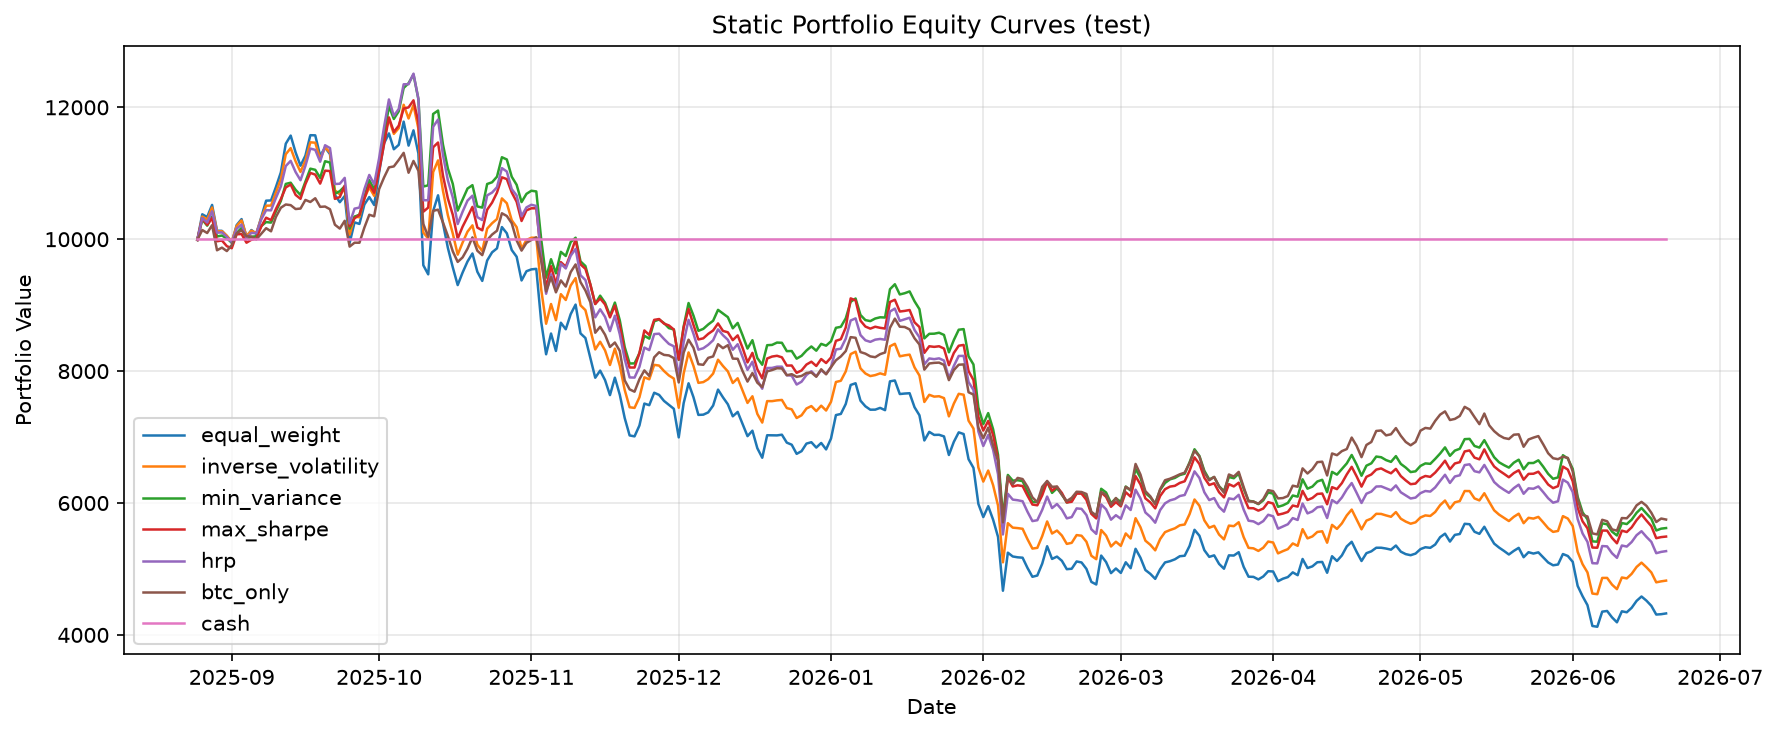

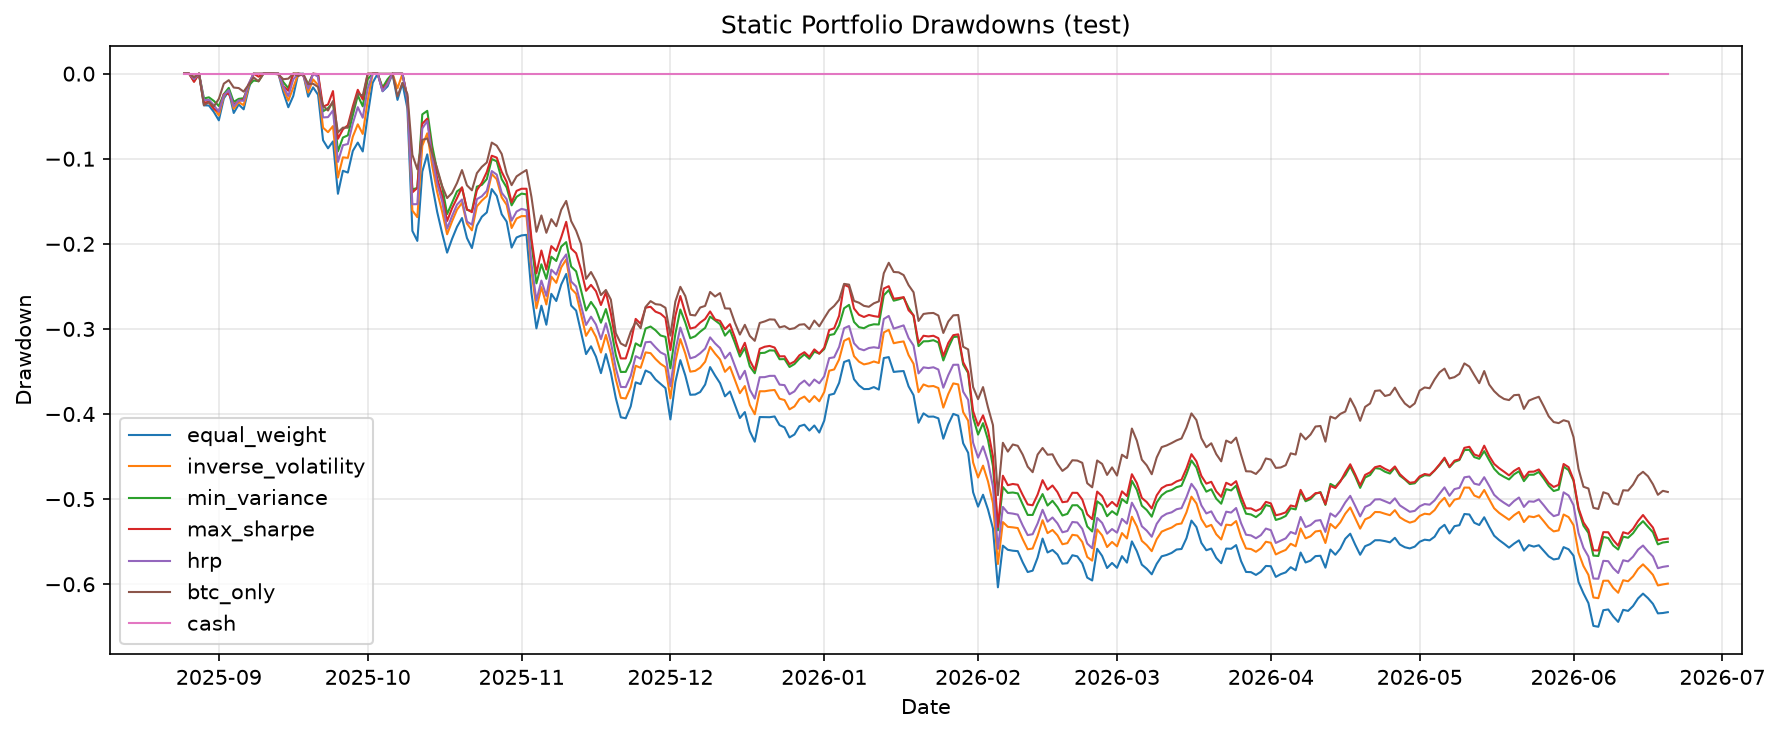

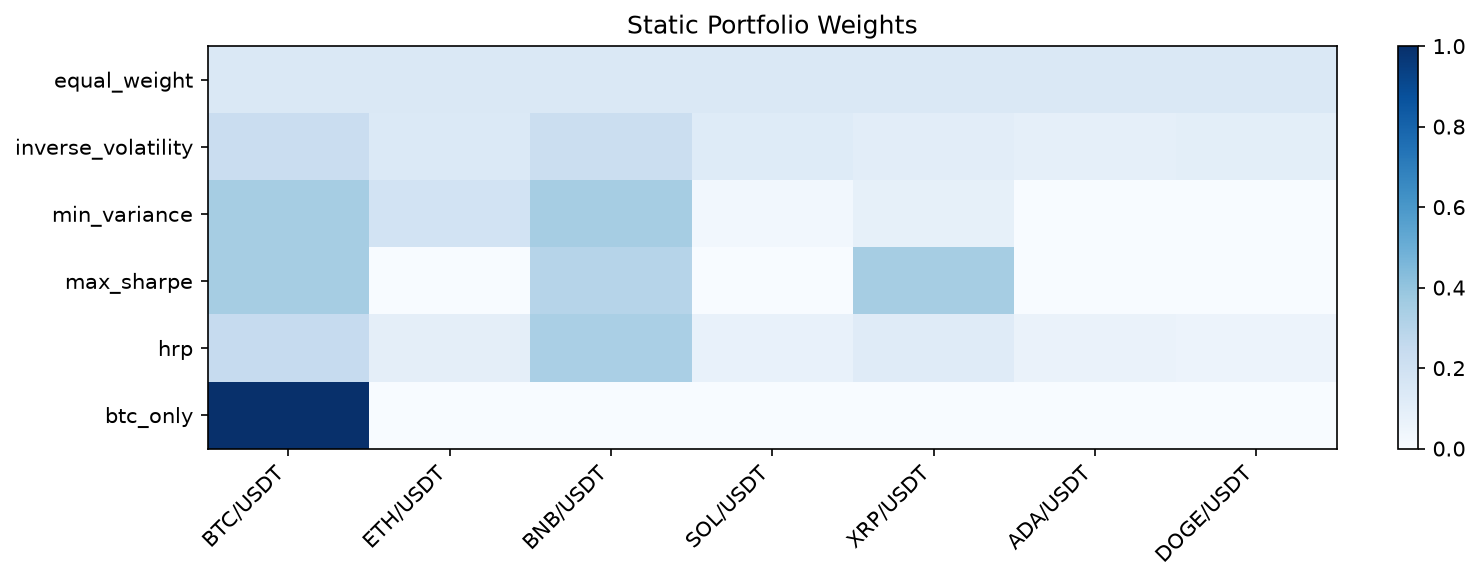

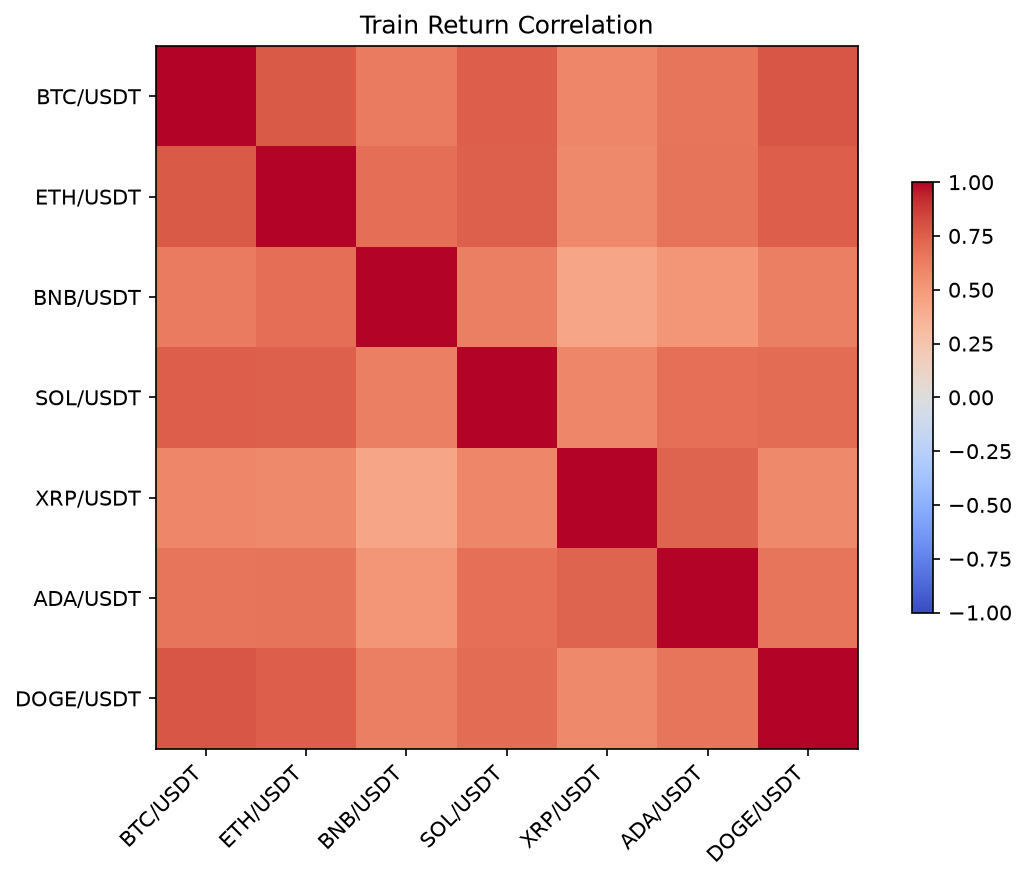

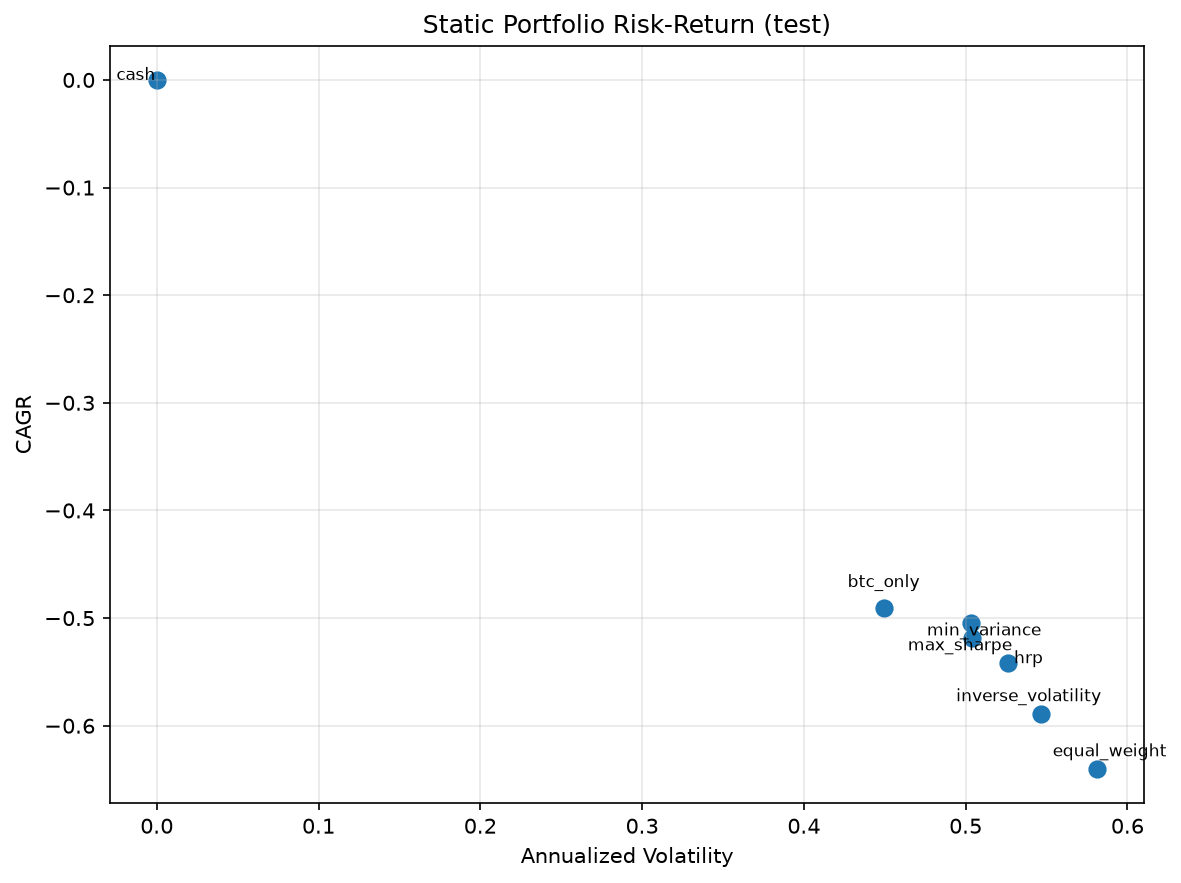

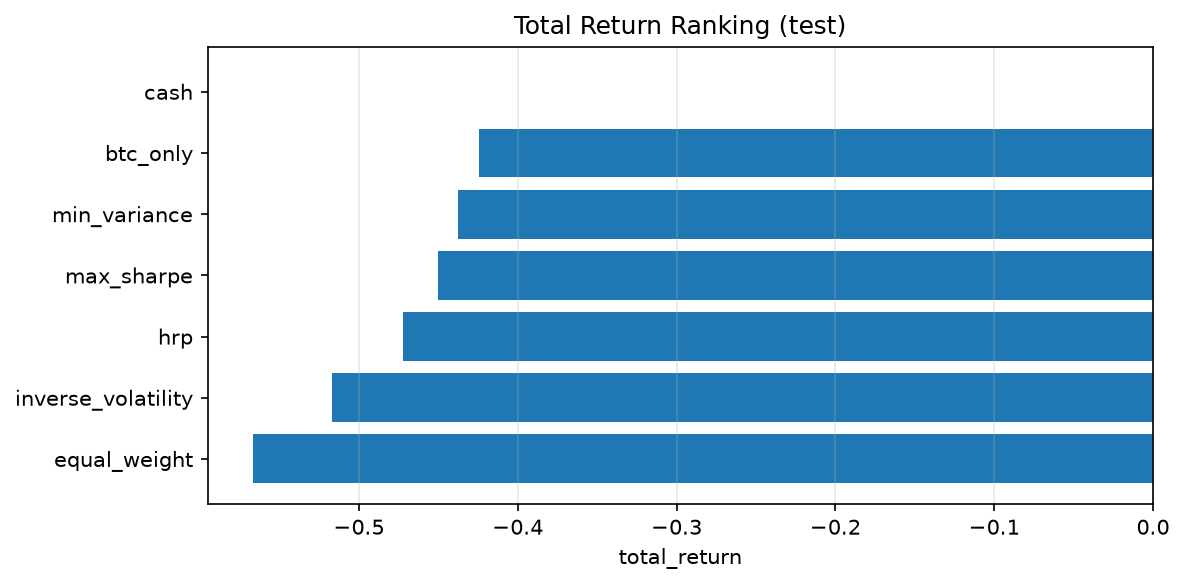

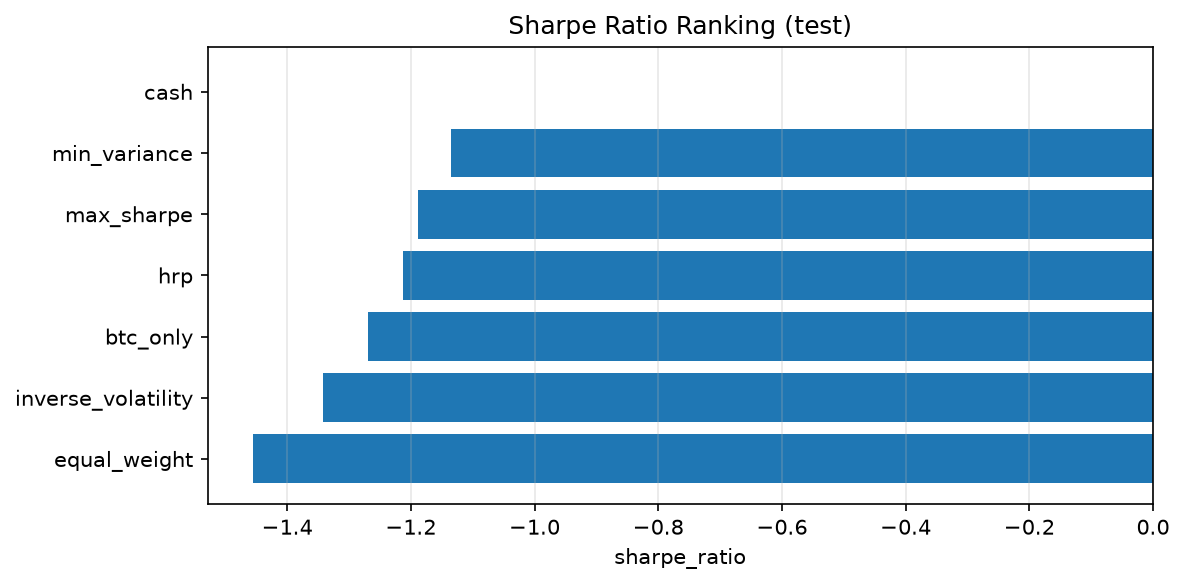

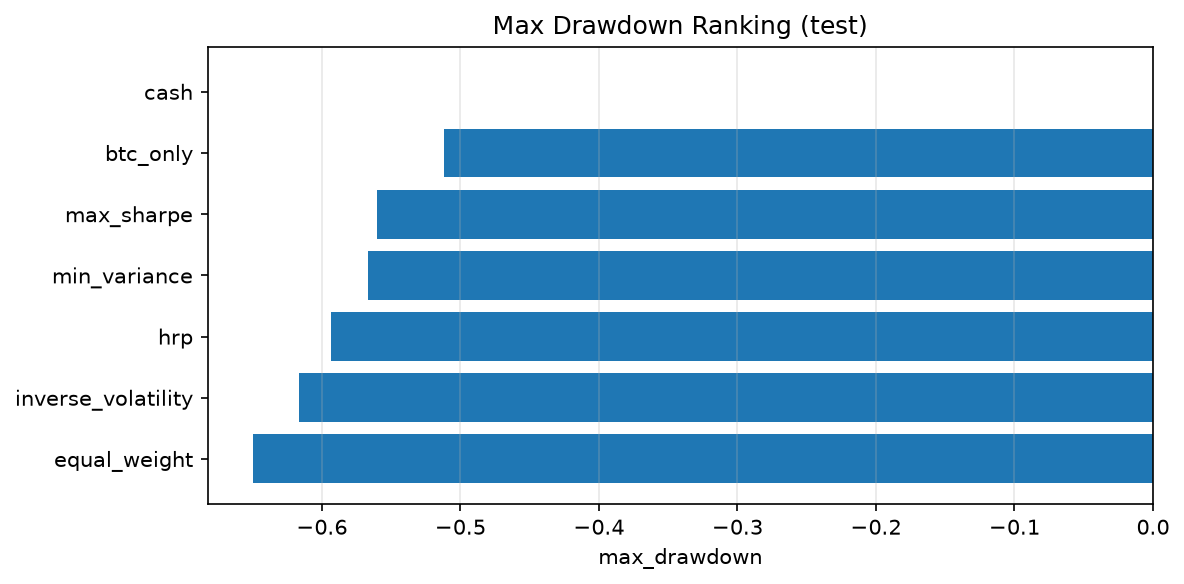

In [11]:
from IPython.display import Image, display

figures_dir = PROJECT_ROOT / "reports" / "figures"
for name in [
    "static_portfolio_equity_curves.png",
    "static_portfolio_drawdowns.png",
    "static_portfolio_weights.png",
    "static_portfolio_correlation_heatmap.png",
    "static_portfolio_risk_return_scatter.png",
    "static_portfolio_total_return_ranking.png",
    "static_portfolio_sharpe_ranking.png",
    "static_portfolio_max_drawdown_ranking.png",
]:
    path = figures_dir / name
    if path.exists():
        display(Image(filename=path))

## 9. Interpretation

- **equal_weight** — simple baseline; no estimation risk.
- **inverse_volatility** — allocates more to low-volatility coins (see `static_portfolio_asset_risk.csv`).
- **min_variance** — risk-focused optimizer; can outperform equal weight in falling markets.
- **max_sharpe** — return/risk trade-off on train estimates; can overfit noisy crypto returns.
- **hrp** — hierarchical risk parity via clustering.
- **btc_only** — 100% BTC buy-and-hold benchmark (`is_benchmark=True`).
- **cash** — flat equity diagnostic benchmark (`is_investable_crypto_portfolio=False`).

Train metrics use the same static weights on the **optimization window**; test metrics use buy-and-hold on the **test period** (no rebalancing).

Crypto assets are highly correlated, so diversification benefit is limited in broad drawdowns. Compare multi-asset portfolios against `btc_only` and `cash` in `static_portfolio_train_test_metrics.csv`.

Agents, dynamic rebalancing, and live trading are out of scope for this stage.